In [2]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../results")

In [3]:
records = []
for json_file in RESULTS_DIR.rglob("*.json"):
    data = json.loads(json_file.read_text())
    for item in data:
        records.append(
            {
                "model": item["model"],
                "task": item["task"],
                "condition": item["condition"],
                "query": item["stimulus"]["query"],
                "expected": item["stimulus"]["expected"],
                "few_shot_examples": item["stimulus"]["few_shot_examples"],
                "metadata": item["stimulus"]["metadata"],
                "response_text": item["response"]["text"],
                "token_logprobs": item["response"]["token_logprobs"],
                "correct": item["score"]["correct"],
                "logprob_correct": item["score"]["logprob_correct"],
                "timestamp": item["timestamp"],
            }
        )

df = pd.DataFrame(records)
print(
    f"Loaded {len(df)} trials from {df['model'].nunique() if len(df) > 0 else 0} models"
)
df.head()

Loaded 20 trials from 1 models


,model,task,condition,query,expected,few_shot_examples,metadata,response_text,token_logprobs,correct,logprob_correct,timestamp
0,smollm2:360m,hierarchical,few_shot,AA BB,same,"[[CC DD, same], [EE FF, same], [GH IJ, differe...","{'pattern': 'same-same', 'source': 'Marcus 2001'}",same,None,True,None,2026-03-24T18:11:24.816476Z
1,smollm2:360m,hierarchical,few_shot,AA AB,different,"[[CC DD, same], [EE FF, same], [GH IJ, differe...","{'pattern': 'same-different', 'source': 'Marcu...",same,None,False,None,2026-03-24T18:11:24.964021Z
2,smollm2:360m,hierarchical,few_shot,CD EF,same,"[[CC DD, same], [EE FF, same], [GH IJ, differe...","{'pattern': 'different-different', 'source': '...",same,None,True,None,2026-03-24T18:11:25.093855Z
3,smollm2:360m,hierarchical,few_shot,CC CD,different,"[[CC DD, same], [EE FF, same], [GH IJ, differe...","{'pattern': 'same-different', 'source': 'Marcu...",same,None,False,None,2026-03-24T18:11:25.226902Z
4,smollm2:360m,hierarchical,zero_shot,AA BB,same,"[[CC DD, same], [EE FF, same], [GH IJ, differe...","{'pattern': 'same-same', 'source': 'Marcus 2001'}",same,None,True,None,2026-03-24T18:11:24.263737Z


In [4]:
if df.empty:
    print("No results loaded yet.")
else:
    accuracy = (
        df.groupby(["model", "task", "condition"])["correct"]
        .mean()
        .mul(100)
        .round(1)
        .unstack("condition")
        .reset_index()
    )
    accuracy.columns.name = None
    print(accuracy.to_string(index=False))

       model         task  few_shot  zero_shot
smollm2:360m hierarchical      50.0       25.0
smollm2:360m       matrix       0.0        0.0
smollm2:360m        rules       0.0        0.0


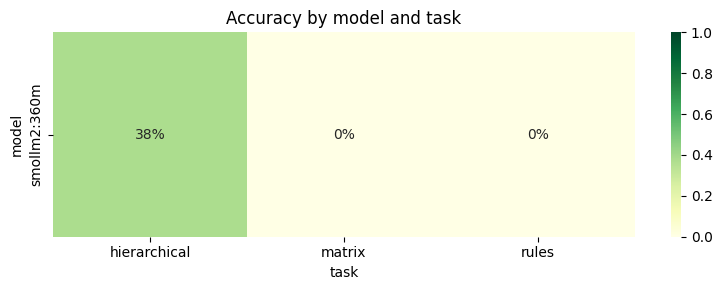

In [5]:
if df.empty:
    print("No results loaded yet.")
else:
    pivot = df.groupby(["model", "task"])["correct"].mean().unstack("task")
    plt.figure(figsize=(8, max(3, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="YlGn", vmin=0, vmax=1)
    plt.title("Accuracy by model and task")
    plt.tight_layout()
    plt.show()

In [6]:
if df.empty or df["logprob_correct"].isna().all():
    print("No log prob data available yet.")
else:
    lp_df = df.dropna(subset=["logprob_correct"])
    g = sns.FacetGrid(lp_df, col="task", row="condition", height=3, aspect=1.5)
    g.map_dataframe(sns.boxplot, x="model", y="logprob_correct")
    g.set_axis_labels("Model", "Log P(correct)")
    g.set_titles("{row_name} | {col_name}")
    plt.tight_layout()
    plt.show()

No log prob data available yet.


In [7]:
if df.empty:
    print("No results loaded yet.")
else:
    df["rule"] = df["metadata"].apply(
        lambda m: m.get("rule") or m.get("pattern", "unknown")
    )
    rule_acc = (
        df.groupby(["task", "rule", "condition"])["correct"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "accuracy", "count": "n"})
        .reset_index()
    )
    rule_acc["accuracy"] = rule_acc["accuracy"].mul(100).round(1)
    print(rule_acc.to_string(index=False))

        task                rule condition  accuracy  n
hierarchical different-different  few_shot     100.0  1
hierarchical different-different zero_shot       0.0  1
hierarchical      same-different  few_shot       0.0  2
hierarchical      same-different zero_shot       0.0  2
hierarchical           same-same  few_shot     100.0  1
hierarchical           same-same zero_shot     100.0  1
      matrix      color-constant  few_shot       0.0  1
      matrix      color-constant zero_shot       0.0  1
      matrix            rotation  few_shot       0.0  1
      matrix            rotation zero_shot       0.0  1
      matrix    size-progression  few_shot       0.0  1
      matrix    size-progression zero_shot       0.0  1
       rules                 AAB  few_shot       0.0  1
       rules                 AAB zero_shot       0.0  1
       rules                 ABA  few_shot       0.0  1
       rules                 ABA zero_shot       0.0  1
       rules                 ABB  few_shot      